<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

digit_recognizer_path = kagglehub.competition_download('digit-recognizer')

print('Data source import complete.')


In [4]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/competitions/digit-recognizer/train.csv'

In [ ]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data.shape

(42000, 785)

In [ ]:
data.sample(1)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
9807,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


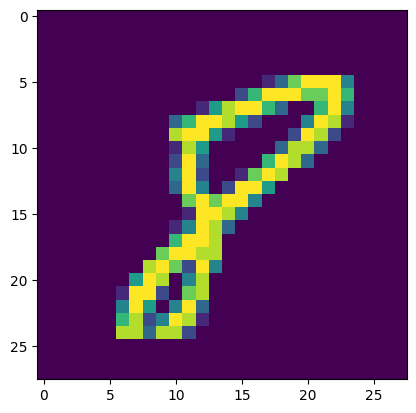

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(data.iloc[18306,1:].values.reshape(28,28))

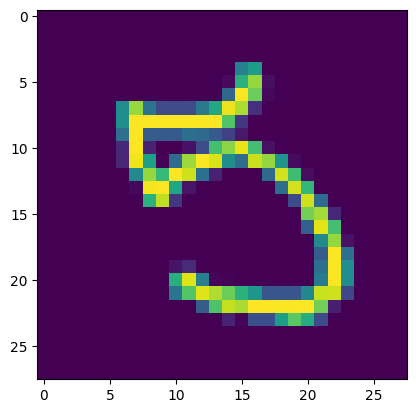

In [ ]:
plt.imshow(data.iloc[1306,1:].values.reshape(28,28))

In [ ]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev=data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]

In [ ]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [ ]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [ ]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train ,0.10, 500)

/tmp/ipykernel_58/3962810796.py:12: RuntimeWarning: overflow encountered in exp
  A = np.exp(Z) / sum(np.exp(Z))
/tmp/ipykernel_58/3962810796.py:12: RuntimeWarning: invalid value encountered in divide
  A = np.exp(Z) / sum(np.exp(Z))


Iteration:  0
[0 0 0 ... 4 4 0] [9 2 2 ... 4 8 9]
0.12848780487804878
Iteration:  10
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  20
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  30
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  40
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  50
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  60
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  70
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  80
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  90
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  100
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  110
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  120
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  130
[0 0 0 ... 0 0 0] [9 2 2 ... 4 8 9]
0.0981219512195122
Iteration:  140


In [ ]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

In [ ]:
test_prediction(0, W1, b1, W2, b2)

In [ ]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

In [ ]:
X = data.iloc[:,1:]
y = data.iloc[:,0]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(X_train ,y_train)

In [ ]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test ,y_pred)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100)

In [ ]:
X_train_trf= pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

ValueError: X has 100 features, but PCA is expecting 41000 features as input.

In [ ]:
X_train.shape

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
X_train_trf.shape

In [ ]:
knn.fit(X_train_trf , y_train)

In [ ]:
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_trf , y_train)
    y_pred = knn.predict(X_test_trf)
    print(accuracy_score(y_test , y_pred))

In [ ]:
import plotly.express as px
y_train_trf =  y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                y=X_train_trf[:,1],
                color=y_train_trf,
                color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()